# 07 · Social Network Analytics
**Process-model step:** *Analyse the data — social network* (Fraud Analytics ch. 5) · **AML concept:** mule rings, shell counterparties, entity resolution & linked parties (Chau ch. 7) · **Statistics:** graph metrics, homophily & permutation tests, community detection, hypergeometric tests, multiple testing

Fraud and laundering are **social**: mules pay each other, shell companies are shared, fraudsters influence their neighbours. Fraud Analytics ch. 5 describes the pipeline we follow:

1. **Build** the network from transactions (nodes, edges, weights, direction)
2. **Featurise**: *neighbourhood* metrics, *centrality* metrics, *collective-inference* (guilt by association)
3. **Community mining**: find groups
4. **Extend** to bipartite graphs (customers ↔ counterparties)
5. Feed the features to the models from notebook 06 and test whether they **add** anything

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, networkx as nx, scipy.sparse as sp, warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, adjusted_rand_score
from statsmodels.stats.multitest import multipletests
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
txn = pd.read_pickle(ak.PROC / "txn_clean.pkl"); kyc = pd.read_pickle(ak.PROC / "kyc_clean.pkl")
feat = pd.read_pickle(ak.PROC / "features.pkl"); truth = ak.load_truth(); n = len(kyc)
y = truth.sort_values("customer_id").is_launderer.values                    # ORACLE, used for grading & the homophily test
ring = (truth.sort_values("customer_id").ring_id.values >= 0)
prod = ak.simulate_dispositions(ak.run_scenario(txn, n), truth)
seed = np.zeros(n, int); seed[prod.loc[prod.str_filed == 1, "customer_id"].unique()] = 1   # KNOWN bad = STR history (what a bank really has)
print(f"known-bad seeds (STR history): {seed.sum()} customers | true launderers: {y.sum()} | mule-ring members: {ring.sum()}")

known-bad seeds (STR history): 83 customers | true launderers: 123 | mule-ring members: 23


## 1 · Build the network from transactions
*Nodes* = customers. *Edges* = money sent between two customers (`transfer_out`), aggregated over the year: number of payments (`cnt`) and value (`w`). Keep both a **directed** graph (who pays whom) and an **undirected** one (who is connected to whom).

nodes 3,500 | undirected edges 20,277 | density 0.0033 | mean degree 11.6 | components 1


directed reciprocity (share of payments that are returned): 0.056


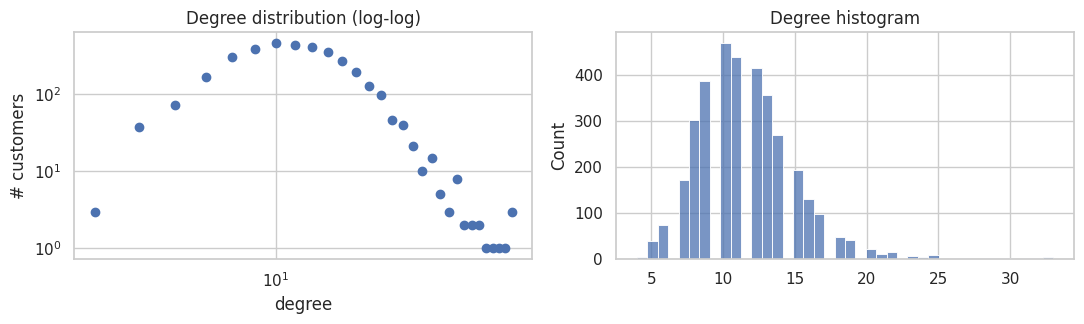

In [2]:
e = txn[(txn.channel == "transfer_out") & (txn.counterparty_id >= 0) & (txn.counterparty_id < n)]
E = e.groupby(["customer_id", "counterparty_id"]).agg(cnt=("txn_id", "size"), w=("amount_usd", "sum")).reset_index()
E = E[E.customer_id != E.counterparty_id]
Gd = nx.from_pandas_edgelist(E, "customer_id", "counterparty_id", ["cnt", "w"], create_using=nx.DiGraph); Gd.add_nodes_from(range(n))
Gu = nx.Graph(); Gu.add_nodes_from(range(n))
for u, v, c, w in E.itertuples(index=False):
    if Gu.has_edge(u, v): Gu[u][v]["cnt"] += c; Gu[u][v]["w"] += w
    else: Gu.add_edge(u, v, cnt=c, w=w)

deg = pd.Series(dict(Gu.degree()))
print(f"nodes {Gu.number_of_nodes():,} | undirected edges {Gu.number_of_edges():,} | density {nx.density(Gu):.4f} | mean degree {deg.mean():.1f} | components {nx.number_connected_components(Gu)}")
print(f"directed reciprocity (share of payments that are returned): {nx.reciprocity(Gd):.3f}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
vc = deg.value_counts().sort_index(); ax[0].loglog(vc.index, vc.values, "o"); ax[0].set(xlabel="degree", ylabel="# customers", title="Degree distribution (log-log)")
sns.histplot(deg, ax=ax[1], bins=40); ax[1].set(title="Degree histogram")
plt.tight_layout(); plt.show()

## 2 · Is suspicious activity *clustered* in the network? (homophily test)
**Homophily** = "birds of a feather": connected customers share risk status. Measure with the **assortativity coefficient** r (−1…+1; 0 = no clustering) and test it with a **permutation test**: shuffle the labels over the nodes, keep the edges, recompute r.

In [3]:
U = np.array([[a, b] for a, b in Gu.edges()]); eu, ev = U[:, 0], U[:, 1]

def assortativity(lbl):
    a = np.r_[lbl[eu], lbl[ev]]; b = np.r_[lbl[ev], lbl[eu]]
    m = np.zeros((2, 2)); np.add.at(m, (a, b), 1); m /= m.sum()
    s = (m.sum(1) * m.sum(0)).sum()
    return (np.trace(m) - s) / (1 - s)

rng = np.random.default_rng(0)
res = {}
for name, lbl in {"true launderers (oracle)": y, "known-bad seeds (STR history)": seed, "mule-ring members": ring.astype(int)}.items():
    r_obs = assortativity(lbl); null = np.array([assortativity(rng.permutation(lbl)) for _ in range(1000)])
    res[name] = dict(r_observed=r_obs, null_mean=null.mean(), null_sd=null.std(), z=(r_obs - null.mean()) / null.std(), p_perm=(1 + (null >= r_obs).sum()) / 1001)
pd.DataFrame(res).T

,r_observed,null_mean,null_sd,z,p_perm
true launderers (oracle),0.062,-0.000,0.007,8.883,0.001
known-bad seeds (STR history),0.014,-0.000,0.007,1.983,0.025
mule-ring members,0.201,-0.000,0.007,30.470,0.001


Suspicious customers connect to each other more than chance predicts — driven mainly by the rings — so network features are *worth trying*. Note the test does not say **which** customers to investigate; that needs features and models.

## 3 · Featurisation (Fraud Analytics ch. 5)
**Neighbourhood metrics** (degree, weighted degree, triangles, clustering, k-core), **centrality** (PageRank, betweenness) and **collective inference / guilt by association** (share of a customer's neighbours that are known bad — computed with the customer *excluded* to avoid label leakage).

In [4]:
nodes = np.arange(n)
A = nx.to_scipy_sparse_array(Gu, nodelist=nodes, weight=None, format="csr").astype(float)
deg_v = np.asarray(A.sum(1)).ravel()
out_str = pd.Series(dict(Gd.out_degree(weight="w"))).reindex(nodes).fillna(0).values
in_str = pd.Series(dict(Gd.in_degree(weight="w"))).reindex(nodes).fillna(0).values

net = pd.DataFrame({"customer_id": nodes, "deg": deg_v,
                    "deg_in": pd.Series(dict(Gd.in_degree())).reindex(nodes).values, "deg_out": pd.Series(dict(Gd.out_degree())).reindex(nodes).values,
                    "log_out_value": np.log1p(out_str), "log_in_value": np.log1p(in_str),
                    "triangles": pd.Series(nx.triangles(Gu)).reindex(nodes).values, "clustering": pd.Series(nx.clustering(Gu)).reindex(nodes).values,
                    "core": pd.Series(nx.core_number(Gu)).reindex(nodes).values,
                    "pagerank": pd.Series(nx.pagerank(Gu, weight="cnt")).reindex(nodes).values,
                    "betweenness": pd.Series(nx.betweenness_centrality(Gu, k=150, seed=0)).reindex(nodes).values})
net["log_triangles"] = np.log1p(net.triangles); net["log_pagerank"] = np.log(net.pagerank)

# collective inference: share of neighbours that are known-bad; 2-hop excludes self (diagonal removed)
A2 = (A @ A).tolil(); A2.setdiag(0); A2 = A2.tocsr()
net["nb_bad_1hop"] = (A @ seed) / np.maximum(deg_v, 1)
net["nb_bad_2hop"] = (A2 @ seed) / np.maximum(np.asarray(A2.sum(1)).ravel(), 1)
net.groupby(ring)[["deg", "triangles", "clustering", "pagerank", "betweenness", "nb_bad_1hop"]].mean().rename(index={False: "everyone else", True: "mule-ring members"})

,deg,triangles,clustering,pagerank,betweenness,nb_bad_1hop
everyone else,11.488,1.214,0.021,0.000,0.001,0.028
mule-ring members,26.565,13.783,0.042,0.000,0.004,0.099


In [5]:
cols = ["deg", "triangles", "clustering", "core", "pagerank", "betweenness", "log_out_value", "nb_bad_1hop", "nb_bad_2hop"]
non_seed = seed == 0
au = pd.DataFrame({
    "AUC: ring members vs rest": {c: roc_auc_score(ring, net[c]) for c in cols},
    "AUC: any launderer vs rest": {c: roc_auc_score(y, net[c]) for c in cols},
    "AUC: any launderer vs rest, seeds excluded": {c: roc_auc_score(y[non_seed], net[c][non_seed]) for c in cols}})
au

,AUC: ring members vs rest,AUC: any launderer vs rest,"AUC: any launderer vs rest, seeds excluded"
deg,0.996,0.630,0.663
triangles,1.000,0.597,0.638
clustering,0.825,0.554,0.583
core,0.587,0.554,0.555
pagerank,0.742,0.620,0.579
betweenness,0.983,0.614,0.676
log_out_value,0.734,0.678,0.601
nb_bad_1hop,0.864,0.586,0.624
nb_bad_2hop,0.864,0.590,0.675


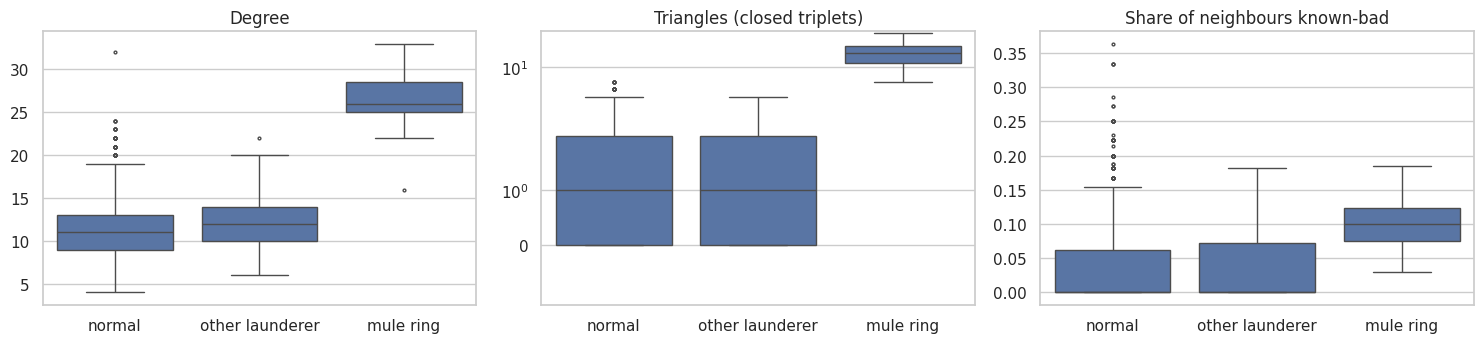

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
grp = np.where(ring, "mule ring", np.where(y == 1, "other launderer", "normal"))
for a, c, t in zip(ax, ["deg", "triangles", "nb_bad_1hop"], ["Degree", "Triangles (closed triplets)", "Share of neighbours known-bad"]):
    sns.boxplot(x=grp, y=net[c], ax=a, order=["normal", "other launderer", "mule ring"], fliersize=2); a.set(title=t, xlabel="", ylabel="")
    if c == "triangles": a.set_yscale("symlog")
plt.tight_layout(); plt.show()

**Reading:** ring members stand out on *degree* and especially **triangles** (their members pay each other in closed loops) — a purely structural signal that no single-customer feature captures. *Guilt by association* helps too, but only where known-bad neighbours exist: seeds come from STR history, which is biased towards structuring, so it says little about *other* typologies (same selection-bias theme as notebooks 05–06).

### Seeing it: a ring versus an equally sized random group

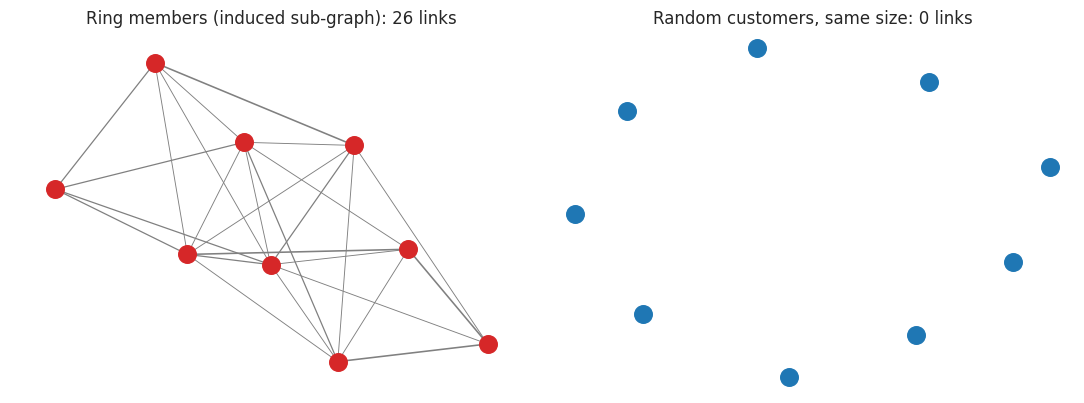

In [7]:
r_id = truth.loc[truth.ring_id == 1, "customer_id"].values if (truth.ring_id == 1).any() else truth.loc[truth.ring_id == 0, "customer_id"].values
rnd = np.random.default_rng(1).choice(np.flatnonzero(~ring), len(r_id), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, nodes_, title, col in [(ax[0], r_id, "Ring members (induced sub-graph)", "tab:red"), (ax[1], rnd, "Random customers, same size", "tab:blue")]:
    H = Gu.subgraph(nodes_); pos = nx.spring_layout(H, seed=2)
    nx.draw_networkx(H, pos, ax=a, node_color=col, node_size=160, with_labels=False, width=[0.4 + 0.25 * H[u][v]["cnt"] for u, v in H.edges()], edge_color="grey")
    a.set_title(f"{title}: {H.number_of_edges()} links"); a.axis("off")
plt.tight_layout(); plt.show()

## 4 · Community mining
Louvain community detection maximises modularity. Then ask, per community: **do launderers appear more often than chance?** — a hypergeometric (one-sided Fisher) test with **Benjamini–Hochberg** correction over all communities. Use a higher `resolution` to find small tight groups (modularity has a *resolution limit*: at 1.0 small rings get swallowed into big communities).

In [8]:
rows = []
for res in (1, 2, 4):
    comms = nx.community.louvain_communities(Gu, weight=None, seed=0, resolution=res)
    lab = np.zeros(n, int)
    for i, c in enumerate(comms):
        for v in c: lab[v] = i
    d = pd.DataFrame({"c": lab, "ring": truth.sort_values("customer_id").ring_id.values})
    purity = d[d.ring >= 0].groupby("ring").c.agg(lambda s: s.value_counts().iloc[0] / len(s))
    rows.append(dict(resolution=res, communities=len(comms), modularity=nx.community.modularity(Gu, comms), median_size=np.median([len(c) for c in comms]),
                     mean_ring_purity=purity.mean(), ARI_vs_KYC_group_id=adjusted_rand_score(lab, kyc.set_index("customer_id").community_id.reindex(nodes).values)))
pd.DataFrame(rows).set_index("resolution")

,communities,modularity,median_size,mean_ring_purity,ARI_vs_KYC_group_id
resolution,,,,,
1,24,0.297,148.500,0.556,0.058
2,79,0.282,43.000,0.722,0.183
4,154,0.271,22.000,0.833,0.313


In [9]:
comms = nx.community.louvain_communities(Gu, weight=None, seed=0, resolution=4)
lab = np.zeros(n, int)
for i, c in enumerate(comms):
    for v in c: lab[v] = i
d = pd.DataFrame({"comm": lab, "y": y, "ring": ring.astype(int)})
g = d.groupby("comm").agg(size=("y", "size"), launderers=("y", "sum"), ring_members=("ring", "sum"))
N, K = n, int(y.sum())
g["p_hypergeom"] = [stats.hypergeom.sf(k - 1, N, K, s) for k, s in zip(g.launderers, g["size"])]
g["q_BH"] = multipletests(g.p_hypergeom, method="fdr_bh")[1]
print(f"{len(g)} communities; {(g.q_BH < .05).sum()} enriched in launderers at FDR 5%")
g.sort_values("p_hypergeom").head(8)

154 communities; 2 enriched in launderers at FDR 5%


,size,launderers,ring_members,p_hypergeom,q_BH
comm,,,,,
10,37,10,9,0.000,0.000
122,23,8,8,0.000,0.000
135,18,4,3,0.003,0.156
49,20,4,0,0.005,0.175
152,24,4,0,0.009,0.275
30,23,3,0,0.045,1.000
111,11,2,0,0.055,1.000
108,14,2,0,0.085,1.000


## 5 · Bipartite graph: customers ↔ external counterparties
Shell companies and shared beneficiaries connect customers **indirectly**. Build the bipartite incidence matrix B (customer × counterparty) and project it: `P = B·Bᵀ` gives, for each customer pair, the **number of shared counterparties**. Two random customers share ≈ 0 counterparties; test each pair's overlap with a **hypergeometric** null (given each customer's number of counterparties) and control the false discovery rate.

In [10]:
ext = txn[txn.counterparty_id >= n]
Bt = ext.groupby(["customer_id", "counterparty_id"]).size().reset_index(name="c")
ids = {c: i for i, c in enumerate(Bt.counterparty_id.unique())}
M = sp.csr_matrix((np.ones(len(Bt)), (Bt.customer_id.values, Bt.counterparty_id.map(ids).values)), shape=(n, len(ids)))
d_c = np.asarray(M.sum(1)).ravel(); Mtot = M.shape[1]
P = sp.triu(M @ M.T, k=1).tocoo()
pairs = pd.DataFrame({"i": P.row, "j": P.col, "shared": P.data})
pairs = pairs[pairs.shared >= 2].copy()
pairs["p"] = stats.hypergeom.sf(pairs.shared - 1, Mtot, d_c[pairs.i], d_c[pairs.j])
pairs["q"] = multipletests(pairs.p, method="fdr_bh")[1]
strong = pairs[pairs.q < 0.001]
print(f"external counterparties: {Mtot:,} | customer pairs sharing >=2: {len(pairs):,} | significant at q<0.001: {len(strong):,}")
Gs = nx.Graph(); Gs.add_edges_from(strong[["i", "j"]].values)
comp = sorted(nx.connected_components(Gs), key=len, reverse=True)
typ = truth.sort_values("customer_id").typology.values
print("largest linked groups (size, typology mix):")
for c_ in comp[:4]: print(" ", len(c_), pd.Series(typ[list(c_)]).value_counts().to_dict())
net["strong_shared_links"] = pd.Series(dict(Gs.degree())).reindex(nodes).fillna(0).values
print("customers with >=1 significant shared-counterparty link:", int((net.strong_shared_links > 0).sum()))
print("AUC of 'shared-counterparty links' for pass_through vs rest:", round(roc_auc_score(typ == "pass_through", net.strong_shared_links), 3))

external counterparties: 4,991 | customer pairs sharing >=2: 4,375 | significant at q<0.001: 131
largest linked groups (size, typology mix):
  19 {'pass_through': 19}
  2 {'none': 2}
  2 {'none': 2}
  2 {'none': 2}
customers with >=1 significant shared-counterparty link: 71
AUC of 'shared-counterparty links' for pass_through vs rest: 1.0


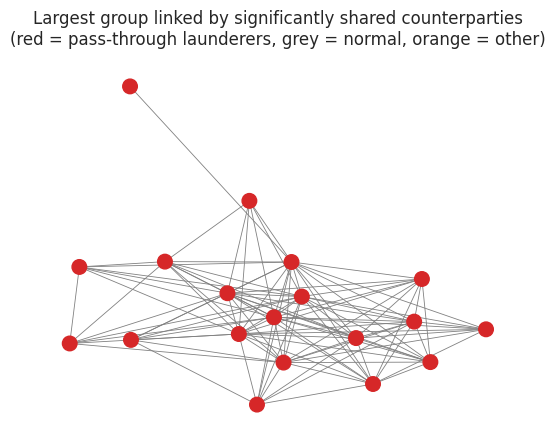

In [11]:
big = list(comp[0]); H = Gs.subgraph(big); pos = nx.spring_layout(H, seed=3, k=0.6)
cmap = {"pass_through": "tab:red", "none": "lightgrey"}
fig, ax = plt.subplots(figsize=(6.5, 5))
nx.draw_networkx(H, pos, ax=ax, node_color=[cmap.get(typ[v], "tab:orange") for v in H.nodes()], node_size=110, with_labels=False, edge_color="grey", width=0.6)
ax.set_title("Largest group linked by significantly shared counterparties\n(red = pass-through launderers, grey = normal, orange = other)"); ax.axis("off"); plt.show()

The **shell counterparties** are used only by pass-through launderers, so the projection lights up that group — a typology that single-customer cash rules, and even the customer-transfer graph, cannot see.

## 6 · Do network features add predictive value? (fair test)
Same random-forest set-up as notebook 06 (oracle labels to isolate the *feature* effect), with and without network features; 12 random 70/30 splits.

In [12]:
XB = ["log_turnover_ratio", "log_max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "hr_share", "log_n_counterparties", "night_share",
      "cash_share_credits", "log_n_txn", "log_mean_amt", "log_credits", "log_amt_wire_in", "log_amt_cash_deposit"]
XN = ["deg", "log_triangles", "clustering", "core", "log_pagerank", "betweenness", "log_out_value", "nb_bad_1hop", "nb_bad_2hop", "strong_shared_links"]
full = feat.merge(net, on="customer_id"); full["ring"] = ring[full.customer_id]
def rf(): return RandomForestClassifier(300, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=-1, random_state=0)

def one(seed_):
    tr, te = train_test_split(full, test_size=0.3, stratify=full.is_launderer, random_state=seed_); out = {}
    for name, cols in (("baseline features", XB), ("baseline + network", XB + XN), ("network only", XN)):
        p = rf().fit(tr[cols], tr.is_launderer).predict_proba(te[cols])[:, 1]; o = np.argsort(-p); top = te.iloc[o[:int(.10 * len(te))]]
        out[name] = dict(AUC=roc_auc_score(te.is_launderer, p), AP=average_precision_score(te.is_launderer, p), recall_top10=top.is_launderer.sum() / te.is_launderer.sum(),
                         ring_recall_top10=top.ring.sum() / max(te.ring.sum(), 1),
                         passthrough_recall_top10=(top.typology == "pass_through").sum() / max((te.typology == "pass_through").sum(), 1))
    return pd.DataFrame(out).T
cmp = pd.concat([one(s) for s in range(12)]).groupby(level=0).mean().loc[["baseline features", "baseline + network", "network only"]]; cmp

,AUC,AP,recall_top10,ring_recall_top10,passthrough_recall_top10
baseline features,0.970,0.740,0.851,0.734,0.914
baseline + network,0.986,0.841,0.935,0.974,0.942
network only,0.734,0.365,0.414,1.000,1.000


### Take-aways
* Network features add most where the **typology is relational** (rings, shared counterparties) and little for solitary behaviours — so report *per-typology* recall, not only AUC.
* Test structure with **permutation / hypergeometric nulls** and correct for the many communities and pairs examined.
* Guilt-by-association depends on the seed labels; if they come from a biased STR history the propagated risk inherits the bias.
* In production, entity resolution (shared phone / address / device) adds edges that transactions alone cannot show (Chau ch. 7).

Save the network features for the deployment notebook:

In [13]:
net.to_pickle(ak.PROC / "network_features.pkl"); print(net.shape, "-> saved")

(3500, 16) -> saved


**Next → `08_evaluation_deployment_monitoring`**